In [1]:
from datetime import datetime

# Print the date and time of the last run (European format)
print("Last run:", datetime.now().strftime("%d.%m.%Y %H:%M:%S"))

Last run: 12.03.2026 11:19:46


---

    title: Demo notebook
    author: Jean Cazalis
    date: Mar 4, 2026
    
---

**Description:**

This notebook demonstrates the use of the `sym_contractions` module to compute the Hamiltonian matrix for a $\mathrm{U}(N)$ one-matrix model. It includes one example of how to compute the Hamiltonian matrix and analyze its properties.

# The `Hamiltonian` object

To assemble the Python object representing a Hamiltonian of the form

$$
H = c_\text{free}(d,m) \,H_\text{free}(m) + \sum_i g_i(d, m)\,H_{\text{int},i}(d, m)
$$

we first build the observables $H_{\text{int},i}(d,m)$ appearing in the interaction terms using `sym_contractions.build_observable`. Each observable have the format: `'{ops}_p{perm}'` where `ops` is the ordered list of operators $X$ and $P$ and `perm` is the permutation specifying the contraction order in the trace.

Here are a few examples:

| Operator | Label | Description |
|----------|-------|-------------|
| $\mathrm{tr}(X^4)$ | `"XXXX_p2341"` | Cyclic trace of four $X$ operators |
| $\mathrm{tr}(X^2)$ | `"XX_p21"` | Trace of two $X$ operators (mass term) |
| $\mathrm{tr}(XPXP)$ | `"XPXP_p2341"` | Alternating $X$–$P$ trace |
| $\mathrm{tr}(XP)^2$ | `"XPXP_p2143"` | Product of traces |

Internally, each interaction term $i$ stores a **coefficient stack** $M_k$ such that

$$
H_{\text{int},i,\text{unnorm}}(d) = \sum_k d^k\, M_k
$$

evaluated at runtime via Horner's method before being normalized.


**Note:** The current implementation encodes permutations as single decimal digits, so operator strings longer than 9 are not supported.


Then, a `Hamiltonian` object stores the full Hamiltonian **symbolically** as a polynomial in `d` (the gauge group rank $N$), so that a single computation can be evaluated at any `d`, `m`, and specified coupling constants without recomputing the contractions.

 Key attributes and methods:

| Attribute / Method | Description |
|--------------------|-------------|
| `ham.Lambda` | Cutoff $\Lambda$ |
| `ham.basis` | List of partition tuples labelling the singlet basis states |
| `ham.size` | Number of basis states $= \sum_{n=0}^{\Lambda} p(n)$ |
| `ham.K` | Max operator count across all interaction terms |
| `ham.is_even`, `ham.is_hermitian` | Parity / hermiticity flags propagated from the operator data |
| `ham.evaluate(d, coupling=..., mass=..., ground_state_only=False)` | Evaluate at a given $d$; returns an `EvaluatedHamiltonian` with `.matrix`, `.basis`, `.h_free`, `.h_int` |

TO BE COMPLETED.

Basis states are **integer partitions** ordered by excitation level $\lvert R\rvert = \sum_i R_i$, then reverse-lexicographically within each level:

$$
(), \; (1,), \; (2,), (1{,}1), \; (3,), (2{,}1), (1{,}1{,}1), \; \ldots
$$

# Example: $\mathrm{tr}(X^4)$

We construct the Hamiltonian for the single interaction term $\mathrm{tr}(X^4)$ with cutoff $\Lambda = 14$ and mass $m = 1/2$.

`build_observables` runs the full pipeline: it calls `generate_data.sh` (steps 1–6) to produce the woven-contraction JSON and the GAP coset representatives, then loads them and assembles the `Observables` objects. If the data files already exist and are up to date, the Mathematica/GAP steps are skipped automatically. If the observables have been already built, they are loaded directly from disk.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

from sym_contractions import PROJECT_ROOT, HamiltonianSparse, build_observables

## Construct the `Hamiltonian` object

In [ ]:
t0 = time.perf_counter()
LAMBDA = 22

observables = build_observables(
    ["XXXX_p2341"],
    Lambda=LAMBDA,
    mass=0.5,
    verbose=True,
    clean=True,  # To clean the data directory before computing (fresh startup)
    save=True,  # To save the built observables to disk for future runs
    storage="sparse",  # "dense" or "sparse" (sparse is better in most cases)
    parallel=False,
)
ham = HamiltonianSparse(observables=observables, Lambda=LAMBDA, default_mass=0.5)

print(f"\nDone in {time.perf_counter() - t0:.1f}s")
print(ham.summary())

Loading saved observable: /home/jcazalis/Projects/02_DESY/05_matrix-models/twobraner/data/processed/observables/XXXX_p2341_Lambda14_sparse.npz

Done in 0.0s
Hamiltonian(label=XXXX_p2341, Λ=14, storage=sparse, mass=0.5, basis_size=508, max_poly_degree=17, nonzero_elements=9328)


In [4]:
print("Hamiltonian summary:")
print("=" * 80)
print(f"Labels        = {ham.labels}")
print(f"Λ             = {ham.Lambda}")
print(f"Basis size    = {ham.size}  (partitions up to excitation {ham.Lambda})")
print(f"K             = {ham.K}     (max operator count)")
print(f"is_even       = {ham.is_even}")
print(f"is_hermitian  = {ham.is_hermitian}")
print(f"max poly deg  = {ham.max_degree}")
print(f"storage kind  = {ham.storage_kind}")
print()
print("First 10 basis states:", ham.basis[:10])

Hamiltonian summary:
Labels        = ['XXXX_p2341']
Λ             = 14
Basis size    = 508  (partitions up to excitation 14)
K             = 4     (max operator count)
is_even       = True
is_hermitian  = True
max poly deg  = 17
storage kind  = sparse

First 10 basis states: [(), (1,), (2,), (1, 1), (3,), (2, 1), (1, 1, 1), (4,), (3, 1), (2, 2)]


## Evaluate for specific coupling, mass, and dimension

In [5]:
g0 = 1.0
mass = 2
dim = 7


# Coupling can be a float, or a callable in d and m
def coupling(d, m):
    return m**2 * g0 / d


H = ham.evaluate(d=dim, coupling=coupling, mass=mass, ground_state_only=True)

# print(f"Normalized ground state energy: {np.linalg.eigvalsh(H)[0] / dim**2:.5f}")
print(
    f"Normalized ground state energy: {sp.sparse.linalg.eigsh(H, k=1, which='SA', return_eigenvectors=False)[0] / dim**2:.5f}"
)

Normalized ground state energy: 1.30367


## Ground state analysis

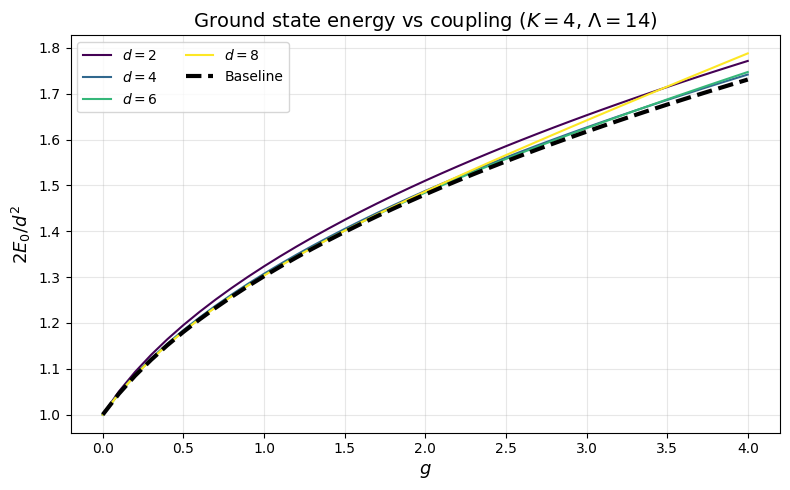

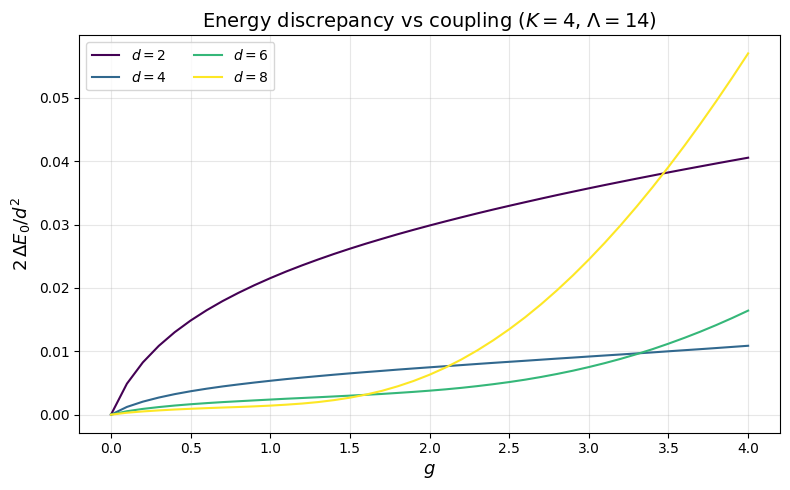

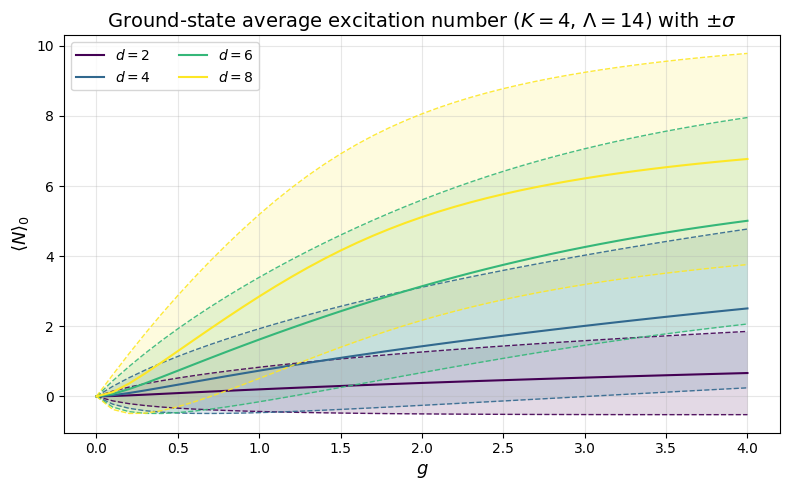

In [7]:
# Load the baseline data for plotting - analytical values in the mean-field regime
baseline = np.loadtxt(
    PROJECT_ROOT / "data" / "raw" / "baseline_numpy.txt", delimiter=","
)


def analyze_GS(ham, gMax, dList, Lambda):
    gg = np.linspace(0, gMax, 41)
    dd = dList

    gs_EN = np.zeros((len(dd), gg.shape[0]))
    gs_EN_std = np.zeros((len(dd), gg.shape[0]))
    gs_energies = np.zeros((len(dd), gg.shape[0]))

    for i, d in enumerate(dd):
        for j, g in enumerate(gg):

            def coupling(d_val, m, _g=g):
                return m**2 * _g / d_val

            H = ham.evaluate(d=d, coupling=coupling, mass=2, ground_state_only=True)
            e, psi = sp.sparse.linalg.eigsh(H, k=1, which="SA")
            psi0 = psi.T[0]
            gs_energies[i, j] = e[0] / d**2

            en_mean, en_std = ham.average_excitation_number(
                d, psi0, ground_state_only=True, return_std=True
            )
            gs_EN[i, j] = float(np.real(en_mean))
            gs_EN_std[i, j] = float(np.real(en_std))

    # Plot 1: ground-state energy
    fig, ax = plt.subplots(figsize=(8, 5))

    d_values_to_plot = dList
    colors = plt.cm.viridis(np.linspace(0, 1, len(d_values_to_plot)))
    for color, d_plot in zip(colors, d_values_to_plot):
        if d_plot not in dd:
            continue
        idx = dd.index(d_plot)
        ax.plot(
            gg, gs_energies[idx], label=f"$d = {d_plot}$", color=color, linewidth=1.5
        )

    baseline_arr = np.array(baseline)
    mask = baseline_arr[:, 0] <= gMax
    ax.plot(
        baseline_arr[mask, 0],
        baseline_arr[mask, 1],
        "k--",
        linewidth=3.0,
        label="Baseline",
        zorder=5,
    )

    ax.set_xlabel(r"$g$", fontsize=13)
    ax.set_ylabel(r"$2 E_0 / d^2$", fontsize=13)
    ax.set_title(
        rf"Ground state energy vs coupling ($K=4$, $\Lambda={Lambda}$)", fontsize=14
    )
    ax.legend(fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Plot 2: energy discrepancy relative to baseline
    baseline_interp = np.interp(gg, baseline_arr[:, 0], baseline_arr[:, 1])
    rel_diff = gs_energies - baseline_interp[None, :]

    fig, ax = plt.subplots(figsize=(8, 5))
    for color, d_plot in zip(colors, d_values_to_plot):
        if d_plot not in dd:
            continue
        idx = dd.index(d_plot)
        ax.plot(gg, rel_diff[idx], label=f"$d = {d_plot}$", color=color, linewidth=1.5)

    ax.set_xlabel(r"$g$", fontsize=13)
    ax.set_ylabel(r"$2\,\Delta E_0 / d^2$", fontsize=13)
    ax.set_title(
        rf"Energy discrepancy vs coupling ($K=4$, $\Lambda={Lambda}$)", fontsize=14
    )
    ax.legend(fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # Plot 3: average excitation number of the ground state with ±σ band
    fig, ax = plt.subplots(figsize=(8, 5))
    for color, d_plot in zip(colors, d_values_to_plot):
        if d_plot not in dd:
            continue
        idx = dd.index(d_plot)
        mean_curve = gs_EN[idx]
        std_curve = gs_EN_std[idx]
        upper = mean_curve + std_curve
        lower = mean_curve - std_curve

        ax.plot(gg, mean_curve, label=f"$d = {d_plot}$", color=color, linewidth=1.5)
        ax.fill_between(
            gg,
            lower,
            upper,
            color=color,
            alpha=0.15,
            linewidth=0,
        )
        ax.plot(gg, upper, color=color, linestyle="--", linewidth=1.0, alpha=0.9)
        ax.plot(gg, lower, color=color, linestyle="--", linewidth=1.0, alpha=0.9)

    ax.set_xlabel(r"$g$", fontsize=13)
    ax.set_ylabel(r"$\langle N \rangle_0$", fontsize=13)
    ax.set_title(
        rf"Ground-state average excitation number ($K=4$, $\Lambda={Lambda}$) with $\pm\sigma$",
        fontsize=14,
    )
    ax.legend(fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    return gs_energies, gs_EN, gs_EN_std


gMax = 4.0
dList = [2, 4, 6, 8]
gs_energies, gs_EN, gs_EN_std = analyze_GS(ham, gMax, dList, LAMBDA)